# Data Pre-Processing -- Tripadvisor Attractions

In [1]:
import os
from bs4 import BeautifulSoup
import pandas as pd
import json
import geopandas as gpd
from collections import Counter
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time
from geopy.distance import geodesic

## read in html files scraped in previous notebook

In [2]:
with open('tripadvisor_attractions_filtered.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)

## retrieve addresses for the attractions

I can see that the page of a lot of attractions contains an address I can extract.

In [3]:
addresses = []

for i in range(len(df)):
    filepath = f'attraction_pages/attraction_{i}.html'
    
    if not os.path.exists(filepath):
        addresses.append(None)
        continue
    
    with open(filepath, 'r', encoding='utf-8') as f:
        soup = BeautifulSoup(f.read(), 'html.parser')
    
    # Address is in a span with 'ezezH' in classes, but skip 'Skip to main content'
    address = None
    for span in soup.find_all('span', class_=lambda c: c and 'ezezH' in c):
        text = span.get_text(strip=True)
        if 'Iceland' in text and 'Skip' not in text:
            address = text
            break
    
    addresses.append(address)



In [4]:
df['address'] = addresses

I need to see how successful this was/how many attractions are missing addresses.

In [5]:
print(f"Addresses found: {df['address'].notna().sum()} / {len(df)}")
print(f"Missing addresses: {df['address'].isna().sum()}")

Addresses found: 592 / 1112
Missing addresses: 520


In [6]:
df[['name', 'address']].head(10)

,name,address
0,Hallgrimskirkja,"Hallgrimstorgi 1, Reykjavik 101 Iceland"
1,Perlan,"Öskjuhlíð, Reykjavik 105 Iceland"
2,Glacier Lagoon,"Skaftafell National Park Route 1, Jokulsarlon ..."
3,Gullfoss Falls,None
4,Sky Lagoon,"Vesturvör 44-48, Kopavogur 200 Iceland"
5,Skogafoss,None
6,Blue Lagoon,"Nordurljosavegur 9, Grindavik 240 Iceland"
7,Harpa Concert Hall and Conference Centre,"Austurbakki 2, Reykjavik 101 Iceland"
8,Thingvellir National Park,None
9,Seljalandsfoss waterfall,None


In [7]:
# Check how many missing addresses are natural vs urban attractions
missing = df[df['address'].isna()]

# Look at categories of missing ones
cats_missing = Counter(cat for cats in missing['category'] for cat in cats)
print("Categories with missing addresses:")
for cat, count in cats_missing.most_common(20):
    print(f"  {count:4d}  {cat}")

Categories with missing addresses:
    61  Waterfalls
    61  Geologic Formations
    47  Points of Interest & Landmarks
    37  Speciality & Gift Shops
    27  Churches & Cathedrals
    22  Historic Sites
    20  Nature & Wildlife Areas
    18  Monuments & Statues
    17  Mountains
    16  Hot Springs & Geysers
    14  Beaches
    14  Lighthouses
    12  Bodies of Water
    12  Speciality Museums
    12  Spas
    11  Caverns & Caves
    11  Scuba & Snorkelling
    10  Hiking Trails
     8  Farms
     8  Scenic Walking Areas


There are geocoordinates on the page of each attraction, so I might be able to use those.

In [8]:
for i in [2, 3, 5, 8, 9]:  # these are the ones missing addresses (waterfalls, national parks etc.)
    with open(f'attraction_pages/attraction_{i}.html', 'r', encoding='utf-8') as f:
        soup = BeautifulSoup(f.read(), 'html.parser')
    
    for script in soup.find_all('script', type='application/ld+json'):
        try:
            data = json.loads(script.string)
            if 'geo' in data:
                print(f"attraction_{i} ({df.iloc[i]['name']}): {data['geo']}")
                break
        except:
            continue
    else:
        print(f"attraction_{i} ({df.iloc[i]['name']}): no geo found")

attraction_2 (Glacier Lagoon): {'@type': 'GeoCoordinates', 'latitude': 64.04855, 'longitude': -16.179256}
attraction_3 (Gullfoss Falls): {'@type': 'GeoCoordinates', 'latitude': 64.32707, 'longitude': -20.119947}
attraction_5 (Skogafoss): {'@type': 'GeoCoordinates', 'latitude': 63.532017, 'longitude': -19.511282}
attraction_8 (Thingvellir National Park): {'@type': 'GeoCoordinates', 'latitude': 64.28218, 'longitude': -21.076447}
attraction_9 (Seljalandsfoss waterfall): {'@type': 'GeoCoordinates', 'latitude': 63.6156, 'longitude': -19.988611}


This worked and in fact is more useful for me.

## retrieve geocoordinates for the attractions

In [9]:
latitudes = []
longitudes = []

for i in range(len(df)):
    filepath = f'attraction_pages/attraction_{i}.html'
    
    if not os.path.exists(filepath):
        latitudes.append(None)
        longitudes.append(None)
        continue
    
    with open(filepath, 'r', encoding='utf-8') as f:
        soup = BeautifulSoup(f.read(), 'html.parser')
    
    lat, lon = None, None
    for script in soup.find_all('script', type='application/ld+json'):
        try:
            data = json.loads(script.string)
            if 'geo' in data:
                lat = data['geo']['latitude']
                lon = data['geo']['longitude']
                break
        except:
            continue
    
    latitudes.append(lat)
    longitudes.append(lon)

df['latitude'] = latitudes
df['longitude'] = longitudes

In [10]:
print(f"Coordinates found: {df['latitude'].notna().sum()} / {len(df)}")
print(f"Missing coordinates: {df['latitude'].isna().sum()}")

Coordinates found: 996 / 1112
Missing coordinates: 116


This worked much better than the addresses, and I was able to retrieve the coordinates for almost 90% of attractions.

In [11]:
df[['name', 'latitude', 'longitude']].head(10)

,name,latitude,longitude
0,Hallgrimskirkja,64.141970,-21.926970
1,Perlan,64.129210,-21.919050
2,Glacier Lagoon,64.048550,-16.179256
3,Gullfoss Falls,64.327070,-20.119947
4,Sky Lagoon,64.116486,-21.946290
5,Skogafoss,63.532017,-19.511282
6,Blue Lagoon,63.880116,-22.448790
7,Harpa Concert Hall and Conference Centre,64.150246,-21.932280
8,Thingvellir National Park,64.282180,-21.076447
9,Seljalandsfoss waterfall,63.615600,-19.988611


In [12]:
# check some random ones to see if coordinates are matching

# df[['name', 'latitude', 'longitude', 'link']].sample(20)

In [13]:
# looks like the coordinates above are pretty accurate

I need to explore more which attractions are missing coordinates.

In [14]:
missing_coords = df[df['latitude'].isna()]
print(f"Missing: {len(missing_coords)}")
print(missing_coords[['name', 'category']])

Missing: 116
                                                   name  \
150                            Volcano Eyjafjallajokull   
178                                   Skaftafellsjökull   
193                          Fimmvorduhals Hiking Trail   
206                                      Eldborg Crater   
214                                         Old Harbour   
...                                                 ...   
1010  Byggðasafn Húnvetninga Og Strandamanna -Reykja...   
1023                             Radgjafa og Nuddsetrid   
1030                                     Madison Ilmhus   
1052                                 Lundinn The Puffin   
1071                                Hafnarfjarðarkirkja   

                             category  
150                        [Volcanos]  
178             [Geologic Formations]  
193                   [Hiking Trails]  
206             [Geologic Formations]  
214                         [Marinas]  
...                               ... 

In [15]:
cats_missing_coords = Counter(cat for cats in missing_coords['category'] for cat in cats)
print("Categories with missing coordinates:")
for cat, count in cats_missing_coords.most_common(20):
    print(f"  {count:4d}  {cat}")

Categories with missing coordinates:
    13  Geologic Formations
    10  Points of Interest & Landmarks
    10  Mountains
    10  Waterfalls
     9  Speciality & Gift Shops
     7  Historic Sites
     7  Churches & Cathedrals
     5  Hiking Trails
     5  Nature & Wildlife Areas
     5  Monuments & Statues
     4  Scuba & Snorkelling
     3  Lighthouses
     3  Religious Sites
     3  Game & Entertainment Centers
     3  Spas
     2  Volcanos
     2  Islands
     2  Ferries
     2  Speciality Museums
     2  Scenic Walking Areas


In [16]:
# I can try to retrieve the missing ones from Nominatim but have to be careful that they are retrieved correctly

## using Nominatim to retrieve missing results

In [17]:
# empty list to store results so that I can check on them before adding them to the main df
geocoded_results = []

# get only the rows where the lat/lon is missing
missing_df = df[df['latitude'].isna()]

# use Nominatim
geolocator = Nominatim(user_agent="iceland_attractions_thesis")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

# loop over rows and try to retrieve locations
for i, row in missing_df.iterrows():
    query = f"{row['name']}, Iceland"
    print(f"Geocoding index {i}: {query}")
    
    try:
        location = geocode(query)
        if location:
            # Append a dictionary with the original index and new data
            geocoded_results.append({
                'original_index': i,
                'name': row['name'],
                'found_address': location.address, # Useful for manual verification
                'new_lat': location.latitude,
                'new_lon': location.longitude
            })
            print(f"  → Found: {location.latitude}, {location.longitude}")
        else:
            print(f"  → Not found")
    except Exception as e:
        print(f"  → Error: {e}")

# add to the  review dataframe
review_df = pd.DataFrame(geocoded_results)

print(f"\nReview dataframe created with {len(review_df)} entries.")

Geocoding index 150: Volcano Eyjafjallajokull, Iceland
  → Found: 63.6299863, -19.6213878
Geocoding index 178: Skaftafellsjökull, Iceland
  → Found: 64.0611375, -16.8759757
Geocoding index 193: Fimmvorduhals Hiking Trail, Iceland
  → Not found
Geocoding index 206: Eldborg Crater, Iceland
  → Not found
Geocoding index 214: Old Harbour, Iceland
  → Found: 64.1511479, -21.9443846
Geocoding index 217: Volcano Hekla, Iceland
  → Found: 63.9927006, -19.6658171
Geocoding index 228: Silfra, Iceland
  → Found: 64.2551903, -21.1169415
Geocoding index 248: Arnarstapi-Hellnar Hike, Iceland
  → Not found
Geocoding index 258: Storhofdi (Great Cape), Iceland
  → Not found
Geocoding index 263: Reynisfjall, Iceland
  → Found: 63.4400532, -19.0322471
Geocoding index 269: Thorsmork, Iceland
  → Found: 63.6866761, -19.5209964
Geocoding index 275: Bolafjall, Iceland
  → Found: 66.1783748, -23.3315884
Geocoding index 277: Hallormsstadur Forestry Reserve, Iceland
  → Not found
Geocoding index 298: Selfoss (W

As I noticed that this can be tricky, I will now manually review the ones where Nominatim found coordinates.

In [18]:
# review_df.iloc[0:60]

In [19]:
'''
31 - good enough
32 - good
33 - good
34 - good 
35 - good
36 - good
37 - good
38 - good
39 - good
40 - good
41 - good 
42 - good
43 - good 
44 - good
45 - good
46 - good
47 - good
48 - good
49 - good
50 - remove, bay will cause issues
51 - remove, area will cause issues
52 - good
53 - good
54 - remove, incorrect
55 - remove, incorrect
56 - good
57 - good
58 - good
'''

'\n31 - good enough\n32 - good\n33 - good\n34 - good \n35 - good\n36 - good\n37 - good\n38 - good\n39 - good\n40 - good\n41 - good \n42 - good\n43 - good \n44 - good\n45 - good\n46 - good\n47 - good\n48 - good\n49 - good\n50 - remove, bay will cause issues\n51 - remove, area will cause issues\n52 - good\n53 - good\n54 - remove, incorrect\n55 - remove, incorrect\n56 - good\n57 - good\n58 - good\n'

In [20]:
'''
0 - good
1 - good
2 - good 
3 - good
4 - good
5 - good
6 - good
7 - good
8 - good
9 - good
10 - good
11 - good
12 - good enough
13 - good
14 - good
15 - good 
16 - good 
17 - good
18 - good
19 - good
20 - good
21 - remove, road 
22 - good
23 - good
24 - remove, island that will cause routing problems
25 - remove, incorrect
26 - good
27 - remove, incorrect
28 - good
29 - good
30 - good
'''

'\n0 - good\n1 - good\n2 - good \n3 - good\n4 - good\n5 - good\n6 - good\n7 - good\n8 - good\n9 - good\n10 - good\n11 - good\n12 - good enough\n13 - good\n14 - good\n15 - good \n16 - good \n17 - good\n18 - good\n19 - good\n20 - good\n21 - remove, road \n22 - good\n23 - good\n24 - remove, island that will cause routing problems\n25 - remove, incorrect\n26 - good\n27 - remove, incorrect\n28 - good\n29 - good\n30 - good\n'

Based on the manual review (me checking the coordinates against what I can find on google maps), I need to remove a few that were retrieved incorrectly.

In [21]:
to_be_removed = [21, 24, 25, 27, 50, 51, 54, 55]

review_df_sorted = review_df.drop(index=to_be_removed)

In [22]:
print(f"Original: {len(review_df)} rows")
print(f"Cleaned: {len(review_df_sorted)} rows")

Original: 59 rows
Cleaned: 51 rows


## using Nominatim to evaluate coordinates extracted from tripadvisor

I can also use this second source to try and verify the coordinates I got from tripadvisor.

In [23]:
def calculate_diff(lat1, lon1, lat2, lon2):
    try:
        return geodesic((lat1, lon1), (lat2, lon2)).km
    except:
        return None

To do this, I will use a threshold after which they are considered a potential issue (if the difference between Tripadvisor and Nominatim is larger than that threshold).

In [24]:
discrepancy_list = []
no_match_list = []
verified_indices = []
error_list = []

# threshold for when to flag
THRESHOLD_KM = 2.0

# only using rows that have coordinates I retrieved from tripadvisor scraped pages
existing_coords_df = df[df['latitude'].notna()]

len(existing_coords_df)

996

In [25]:
# looping over them
for i, row in existing_coords_df.iterrows():
    query = f"{row['name']}, Iceland"
    
    try:
        location = geocode(query)
        if location:
            dist = calculate_diff(row['latitude'], row['longitude'], 
                                  location.latitude, location.longitude)
            
            if dist and dist > THRESHOLD_KM:
                print(f"Significant difference: {dist:.2f} km")
                discrepancy_list.append({
                    'original_index': i,
                    'name': row['name'],
                    'old_lat': row['latitude'],
                    'old_lon': row['longitude'],
                    'new_lat': location.latitude,
                    'new_lon': location.longitude,
                    'distance_km': round(dist, 2),
                    'new_address': location.address
                })

            else:
                # if it is under the threshold it must be match and thus verified
                verified_indices.append(i)
        else:
            print(f"Nominatim couldn't find {row['name']} to compare.")
            no_match_list.append({
                'original_index': i,
                'name': row['name'],
                'old_lat': row['latitude'],
                'old_lon': row['longitude']})
            
            
    except Exception as e:
        print(f"Error checking {i}: {e}")
        error_list.append({
            'original_index': i,
            'name': row['name'],
            'old_lat': row['latitude'],
            'old_lon': row['longitude']})

# create dataframe for easier checking
discrepancy_df = pd.DataFrame(discrepancy_list)

Significant difference: 4.07 km
Nominatim couldn't find Harpa Concert Hall and Conference Centre to compare.
Nominatim couldn't find Víkurfjara Black Sand Beach to compare.
Nominatim couldn't find Reykjadalur Hot Springs to compare.
Nominatim couldn't find Golden Circle Route to compare.
Significant difference: 1750.25 km
Significant difference: 4.63 km
Nominatim couldn't find Fjadrargljufur Canyon to compare.
Nominatim couldn't find Sundhollin Public Baths to compare.
Nominatim couldn't find Volcano Express Iceland to compare.
Nominatim couldn't find Aurora Reykjavík - The Northern Lights Center to compare.
Significant difference: 3.45 km
Nominatim couldn't find Kirkjufell Mountain to compare.
Nominatim couldn't find Arbaer Open Air Museum to compare.
Nominatim couldn't find Gunnuhver Hot Springs to compare.
Significant difference: 4.77 km
Nominatim couldn't find Vatnshellir Lava Cave to compare.
Nominatim couldn't find Skaftafell National Park to compare.
Significant difference: 4.80

In [26]:
len(discrepancy_df)

131

In [27]:
len(no_match_list)

569

In [28]:
len(error_list)

0

This makes sense as there were no items in my loop that went into the exception option (which would have meant something would have not worked in the code). 

In [29]:
len(verified_indices)

296

In [30]:
# discrepancy_df.iloc[30:60]

Overall impression after manual checks: tripadvisor locations are mostly good.

In [31]:
# a few small fixes noted during manual sample check

keep_new = [4, 6, 8, 12, 15, 21]
remove_from_df = [1, 5, 11, 20, 39, 52, 59]

## merging results of manual check ups with data frame

In [32]:
# first merging the checked Nominatim results for missing ones to the original df

for _, row in review_df_sorted.iterrows():
    idx = row['original_index']
    df.at[idx, 'latitude'] = row['new_lat']
    df.at[idx, 'longitude'] = row['new_lon']
    
print(f"Successfully merged {len(review_df_sorted)} rows.")

Successfully merged 51 rows.


In [33]:
print(f"Total rows: {len(df)}")
print(f"Missing Latitude: {df['latitude'].isna().sum()}")

Total rows: 1112
Missing Latitude: 65


In [34]:
# next merging the small changes from the second check into the dataframe

for disc_idx in keep_new:
    # locate relevant row in discrepancy_df
    disc_row = discrepancy_df.loc[disc_idx]
    
    # get index in the original df
    orig_idx = disc_row['original_index']
    
    # update the original df 
    df.at[orig_idx, 'latitude'] = disc_row['new_lat']
    df.at[orig_idx, 'longitude'] = disc_row['new_lon']
    
    print(f"Updated {disc_row['name']} (Index {orig_idx}) with new coordinates.")

Updated Dynjandi (Fjallfoss) (Index 40) with new coordinates.
Updated Hraunfossar (Index 55) with new coordinates.
Updated Vatnajökull Glacier (Index 60) with new coordinates.
Updated Mýrdalsjökull Glacier (Index 80) with new coordinates.
Updated Lofthellir Lava Cave (Index 115) with new coordinates.
Updated Helgafell (Index 186) with new coordinates.


In [35]:
# map the discrepancy indices to the original indices
orig_indices_to_remove = discrepancy_df.loc[remove_from_df, 'original_index'].tolist()

# drop them from the main dataframe
df.drop(index=orig_indices_to_remove, inplace=True)

print(f"Removed {len(orig_indices_to_remove)} rows from the main dataframe.")

Removed 7 rows from the main dataframe.


In [36]:
# some final checks

len(df)

1105

I will remove all rows that still have no coordinates from the dataframe. This is a data issue not easily solvable.

In [37]:
df_geo = df[df['latitude'].notna()].reset_index(drop=True)
print(f"Final dataframe: {len(df_geo)} attractions")

Final dataframe: 1040 attractions


In [38]:
records = df_geo.to_dict(orient='records')
with open('tripadvisor_attractions_geo.json', 'w', encoding='utf-8') as f:
    json.dump(records, f, ensure_ascii=False, indent=2)

print("Saved to tripadvisor_attractions_geo.json")

Saved to tripadvisor_attractions_geo.json


In [39]:
df_geo.head()

,name,link,rating,review_count,category,address,latitude,longitude
0,Hallgrimskirkja,https://www.tripadvisor.com/Attraction_Review-...,4.4,23266,[Churches & Cathedrals],"Hallgrimstorgi 1, Reykjavik 101 Iceland",64.141970,-21.926970
1,Perlan,https://www.tripadvisor.com/Attraction_Review-...,4.5,4305,"[Speciality Museums, Points of Interest & Land...","Öskjuhlíð, Reykjavik 105 Iceland",64.129210,-21.919050
2,Glacier Lagoon,https://www.tripadvisor.com/Attraction_Review-...,4.9,5082,[Bodies of Water],"Skaftafell National Park Route 1, Jokulsarlon ...",64.048550,-16.179256
3,Gullfoss Falls,https://www.tripadvisor.com/Attraction_Review-...,4.7,12522,[Waterfalls],None,64.327070,-20.119947
4,Sky Lagoon,https://www.tripadvisor.com/Attraction_Review-...,4.5,4964,[Thermal Spas],"Vesturvör 44-48, Kopavogur 200 Iceland",64.116486,-21.946290


In [40]:
gdf_tripadvisor = gpd.GeoDataFrame(
    df_geo, geometry=gpd.points_from_xy(df_geo.longitude, df_geo.latitude), crs="EPSG:4326"
)

<Axes: >

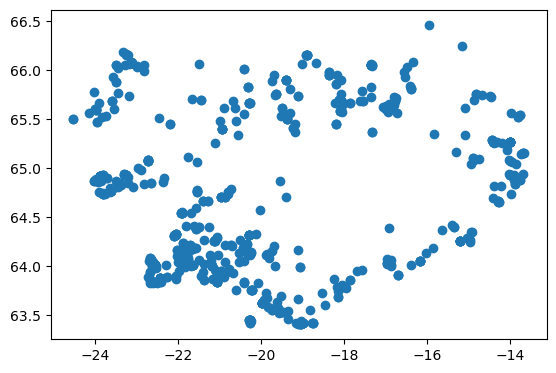

In [41]:
gdf_tripadvisor.plot()

In [42]:
gdf_export = gdf_tripadvisor.copy()
gdf_export['category'] = gdf_export['category'].apply(lambda x: ' • '.join(x) if x else None)
gdf_export.to_file('tripadvisor_attractions_geo.geojson', driver='GeoJSON')
print("Saved!")

Saved!


Now, I have a geodataframe of the attractions with their relevant attributes and their geocoordinates.
Note that as category contains a list, I have to convert it to a string before exporting. When importing, I will convert it to a list again.